## Activation Functions Implementation

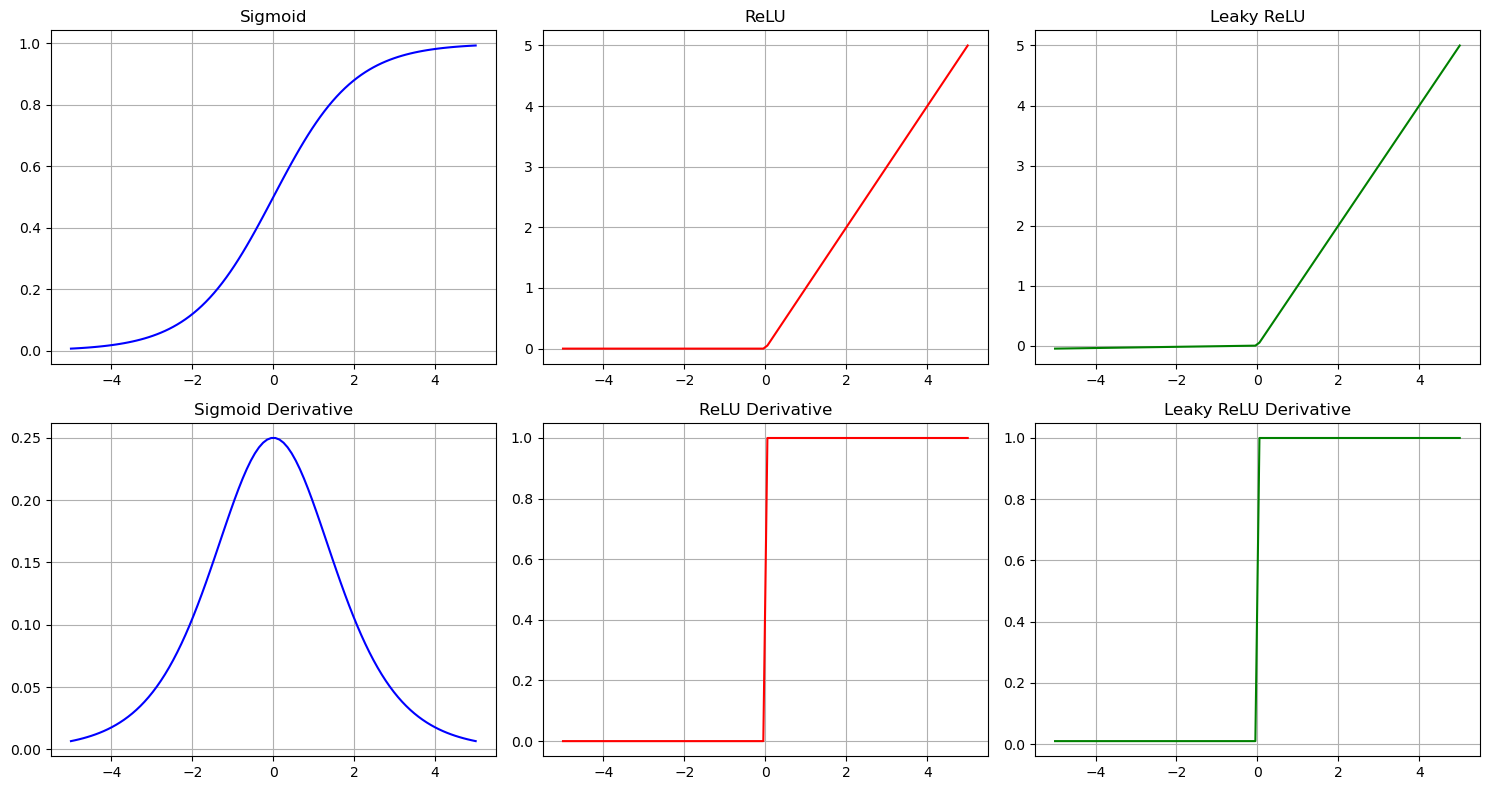

In [1]:
# importing the libraries
import numpy as np
import matplotlib.pyplot as plt

# sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

# relu
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

# leaky relu
def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def leaky_relu_derivative(z, alpha=0.01):
    return np.where(z > 0, 1, alpha)

# plotting all three and their derivatives
z = np.linspace(-5, 5, 100)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# sigmoid
axes[0,0].plot(z, sigmoid(z), color='blue')
axes[0,0].set_title('Sigmoid')
axes[0,0].grid(True)

axes[1,0].plot(z, sigmoid_derivative(z), color='blue')
axes[1,0].set_title('Sigmoid Derivative')
axes[1,0].grid(True)

# relu
axes[0,1].plot(z, relu(z), color='red')
axes[0,1].set_title('ReLU')
axes[0,1].grid(True)

axes[1,1].plot(z, relu_derivative(z), color='red')
axes[1,1].set_title('ReLU Derivative')
axes[1,1].grid(True)

# leaky relu
axes[0,2].plot(z, leaky_relu(z), color='green')
axes[0,2].set_title('Leaky ReLU')
axes[0,2].grid(True)

axes[1,2].plot(z, leaky_relu_derivative(z), color='green')
axes[1,2].set_title('Leaky ReLU Derivative')
axes[1,2].grid(True)

plt.tight_layout()
plt.show()

In [2]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

class NeuralNetworkReLU:
    def __init__(self, learning_rate=0.1, n_iterations=10000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.W1 = None
        self.b1 = None
        self.W2 = None
        self.b2 = None
        self.loss_history = []

    def initialize_weights(self, n_input, n_hidden, n_output):
        self.W1 = np.random.randn(n_input, n_hidden) * 0.01  # back to small init
        self.b1 = np.zeros(n_hidden)
        self.W2 = np.random.randn(n_hidden, n_output) * 0.01
        self.b2 = np.zeros(n_output)

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = relu(self.z1)          # ReLU in hidden layer
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = sigmoid(self.z2)        # sigmoid still at output
        return self.a1, self.a2

    def backward(self, X, y, a1, a2):
        n = len(y)
        delta2 = a2 - y.reshape(-1, 1)
        dW2 = (1/n) * a1.T @ delta2
        db2 = (1/n) * np.sum(delta2, axis=0)
        delta1 = delta2 @ self.W2.T * relu_derivative(self.z1)  # ReLU derivative
        dW1 = (1/n) * X.T @ delta1
        db1 = (1/n) * np.sum(delta1, axis=0)
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def fit(self, X, y):
        self.initialize_weights(n_input=2, n_hidden=4, n_output=1)
        for _ in range(self.n_iter):
            a1, a2 = self.forward(X)
            self.backward(X, y, a1, a2)
            loss = -np.mean(y * np.log(a2 + 1e-8) +
                           (1-y) * np.log(1-a2 + 1e-8))
            self.loss_history.append(loss)

# XOR dataset
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])

# 10 attempts with small initialization
print("ReLU network — small initialization:")
for attempt in range(10):
    np.random.seed(attempt)
    model = NeuralNetworkReLU(learning_rate=0.1, n_iterations=10000)
    model.fit(X_xor, y_xor)
    a1, a2 = model.forward(X_xor)
    predictions = (a2 >= 0.5).astype(int).flatten()
    accuracy = np.mean(predictions == y_xor)
    print(f"Attempt {attempt+1}: predictions={predictions}, accuracy={accuracy*100:.1f}%")

ReLU network — small initialization:
Attempt 1: predictions=[0 1 1 0], accuracy=100.0%
Attempt 2: predictions=[0 1 1 0], accuracy=100.0%
Attempt 3: predictions=[0 1 1 0], accuracy=100.0%
Attempt 4: predictions=[0 0 1 0], accuracy=75.0%
Attempt 5: predictions=[0 0 1 0], accuracy=75.0%
Attempt 6: predictions=[0 1 1 0], accuracy=100.0%
Attempt 7: predictions=[0 1 1 0], accuracy=100.0%
Attempt 8: predictions=[0 1 1 0], accuracy=100.0%
Attempt 9: predictions=[0 1 1 0], accuracy=100.0%
Attempt 10: predictions=[1 1 1 1], accuracy=50.0%
